   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7325 - loss: 0.5501 - val_accuracy: 0.8000 - val_loss: 0.4520
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4544 - val_accuracy: 0.8169 - val_loss: 0.4287
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8034 - loss: 0.4368 - val_accuracy: 0.8213 - val_loss: 0.4179
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8100 - loss: 0.4222 - val_accuracy: 0.8313 - val_loss: 0.4035
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8227 - loss: 0.4031 - val_accuracy: 0.8462 - val_loss: 0.3889
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8355 - loss: 0.3863 - val_accuracy: 0.8494 - val_loss: 0.3767
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8428 - loss: 0.3735 - val_accuracy: 0.8537 - val_loss: 0.3690
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8516 - loss: 0.3649 - val_accuracy: 0.8544 - val_

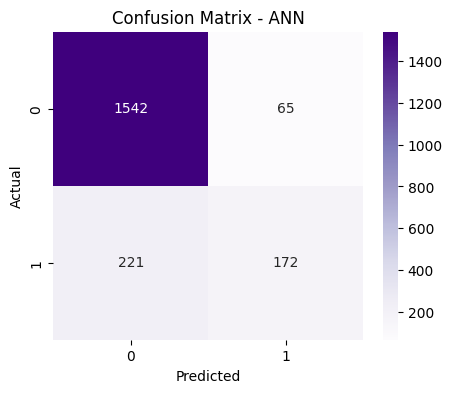

In [1]:
# ================= STEP 1: IMPORT =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ================= STEP 2: LOAD DATA =================
df = pd.read_csv("Churn_Modelling.csv")


print(df.head())


# ================= STEP 3: PREPROCESSING =================
# Drop unnecessary columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])


# Encode categorical
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)


# Split features and target
X = df.drop(columns=['Exited'])
y = df['Exited']


# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)


# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================= STEP 4: BUILD ANN =================
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ================= STEP 5: TRAIN =================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


# ================= STEP 6: PREDICT =================
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)


# ================= STEP 7: EVALUATION =================
print("Accuracy:", accuracy_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)


# Confusion Matrix Image
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN")
plt.show()


